# Radar Cross Section (RCS) Analysis of a Trihedral Corner Reflector
### Cross-Exclusion Clutter Window Variant (Garthwaite et al., 2015, Figure 4.11 / Table 4.5)

**Target location:** GCP03 (ITS Surabaya)
**Sensor:** Sentinel-1A IW SLC → Terrain Corrected (Orb_tnr_Cal_[split_]deb_TC)
**Method:** CoRAL (Corner Reflector Analysis Library), Geoscience Australia

---
This notebook performs the following steps:
1. Reading all SAR scenes available in the target directory, including both full-swath and IW-subswath-split products
2. Automatic detection of the correct Sigma0 band for each scene (full-swath vs. split subswath products may use different band names)
3. Conversion of the CR reference coordinates (UTM → geographic)
4. Automatic search for the sigma0 peak pixel around the reference point
5. Computation of RCS and SCR per scene using CoRAL
6. Summary of the results as a table and as time-series visualizations


## 1. Configuration and Library Imports

In [116]:
import glob
import os
import re
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from rasterio.transform import rowcol
from rasterio.windows import Window
from pyproj import Transformer
import xml.etree.ElementTree as ET

import coral.dataio as dataio_module
from coral.corner_reflector import loop
from coral.cross_exclusion import loop_cross_exclusion

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 120,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Input Parameters

All parameters that need to be adjusted by the user are collected in a single place.

**Note on the dataset structure:** the target directory may contain a mix of two product types:
- **Full-swath** products (`*_Orb_tnr_Cal_deb_TC.data`), which store the calibrated band as `Sigma0_VV`.
- **Split** products (`*_Orb_tnr_Cal_split_deb_TC.data`), which have been limited to a single IW subswath (e.g. IW1) prior to terrain correction, and therefore store the band as `Sigma0_IW1_VV` (or `IW2`/`IW3`, depending on which subswath contains the target).

Because the band name differs between these two product types, `BAND_NAME` below is treated only as the **preferred polarization identifier** (`VV`); the actual band name is resolved automatically per scene in Section 3.

In [117]:
# --- Data path ---
DATA_DIR = "/media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC new"
OUTPUT_DIR = "/media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif"
POLARIZATION = "VV"   # used to auto-detect the Sigma0 band name per scene (see Section 3)

# --- Ground control point (GCP03) reference coordinates, UTM zone 49S ---
GCP_NAME = "GCP03"
GCP_EASTING = 698162.7296
GCP_NORTHING = 9194891.1360
GCP_HEIGHT = 32.1755
GCP_EPSG = "EPSG:32749"   # UTM zone 49S

# --- Sigma0 peak search parameters ---
SEARCH_RADIUS_M = 50      # search radius around the reference point (meters)

# --- CoRAL analysis window parameters ---
SUB_IM = 51                  # half-size of the image crop (pixels)
TARG_WIN_SZ = 4              # target (CR) window size (pixels)
CLT_WIN_SZ = 32              # clutter window size (pixels)
CROSS_WIDTH = 5              # cross-exclusion width (pixels), Table 4.5 Garthwaite et al. (2015), C-band 1.5 m CR

# --- Fallback incidence angle (for Terrain Corrected products without a tie-point grid) ---
THETA_FALLBACK_DEG = 33.71769881802982

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Parameters ready.")

Parameters ready.


## 3. Loading the SAR Scene List and Resolving the Sigma0 Band per Scene

In [118]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.dim")))

print(f"Found {len(files)} scene(s):")
for f in files:
    print(" -", os.path.basename(f))

assert len(files) > 0, "No .dim files found. Please check DATA_DIR." + ""


Found 7 scene(s):
 - S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim
 - S1A_IW_SLC__1SDV_20260503T105005_20260503T105033_064351_081A63_4980_Orb_tnr_split_Cal_deb_TC.dim


Since full-swath products expose the band as `Sigma0_VV`, while split (single-subswath) products expose it as `Sigma0_IW{n}_VV`, the function below inspects the contents of each `.data` directory and resolves the correct band name automatically. Full-swath naming is preferred when both are present; otherwise the available IW subswath band is used.

In [119]:
def resolve_band_name(dim_file, polarization=POLARIZATION):
    """Detect the correct Sigma0 band name for a given scene.

    Full-swath products store the band as ``Sigma0_{pol}``. Products that were
    limited to a single IW subswath prior to terrain correction (i.e. ``split``
    products) instead store it as ``Sigma0_IW{n}_{pol}``. This function inspects
    the scene's ``.data`` directory and returns whichever band is actually present.
    """
    data_dir = dim_file.replace(".dim", ".data")

    full_swath_candidate = f"Sigma0_{polarization}"
    if os.path.isfile(os.path.join(data_dir, f"{full_swath_candidate}.img")):
        return full_swath_candidate

    subswath_candidates = sorted(
        glob.glob(os.path.join(data_dir, f"Sigma0_IW*_{polarization}.img"))
    )
    if subswath_candidates:
        band_file = os.path.basename(subswath_candidates[0])
        return os.path.splitext(band_file)[0]

    raise FileNotFoundError(
        f"No Sigma0_{polarization} band found in {data_dir}. "
        "Check the product content or POLARIZATION setting."
    )


band_map = {}
for f in files:
    scene_name = os.path.basename(f)
    band_map[scene_name] = resolve_band_name(f)
    is_split = "split" in scene_name
    tag = "split / single subswath" if is_split else "full swath"
    print(f"{scene_name}\n    band = {band_map[scene_name]}  ({tag})")

S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim
    band = Sigma0_VV  (full swath)
S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim
    band = Sigma0_IW1_VV  (split / single subswath)
S1A_IW_SLC__1SDV_20260503T105005_20260503T105033_064351_081A63_4980_Orb_tnr_split_Cal_deb_TC.dim
    band = Sigma0_IW1_VV  (split / single subswath)


## 4. Conversion of the Reference Coordinates (UTM → Geographic)

In [120]:
transformer = Transformer.from_crs(GCP_EPSG, "EPSG:4326", always_xy=True)
gcp_lon, gcp_lat = transformer.transform(GCP_EASTING, GCP_NORTHING)

print(f"{GCP_NAME}: E={GCP_EASTING:.4f}, N={GCP_NORTHING:.4f}, H={GCP_HEIGHT:.4f} m")
print(f"{GCP_NAME}: lon={gcp_lon:.8f}, lat={gcp_lat:.8f}")

meters_per_deg_lat = 111320
meters_per_deg_lon = 111320 * np.cos(np.radians(gcp_lat))

radius_deg_lat = SEARCH_RADIUS_M / meters_per_deg_lat
radius_deg_lon = SEARCH_RADIUS_M / meters_per_deg_lon

print(f"Search radius: {SEARCH_RADIUS_M} m -> ±{radius_deg_lon:.6f}° lon, ±{radius_deg_lat:.6f}° lat")

GCP03: E=698162.7296, N=9194891.1360, H=32.1755 m
GCP03: lon=112.79492874, lat=-7.28012077
Search radius: 50 m -> ±0.000453° lon, ±0.000449° lat


## 5. Automatic Search for the Sigma0 Peak Pixel

For each scene, the pixel with the highest sigma0 value is located within the search radius around the CR reference point, using the band resolved for that scene in Section 3.

In [121]:
def find_peak_pixel(dim_file, lon, lat, radius_deg_lon, radius_deg_lat, band, buffer_px=3):
    data_dir = dim_file.replace(".dim", ".data")
    band_path = os.path.join(data_dir, f"{band}.img")

    with rasterio.open(band_path) as src:
        transform = src.transform
        crs = src.crs
        raster_height, raster_width = src.height, src.width

        lon_min, lon_max = lon - radius_deg_lon, lon + radius_deg_lon
        lat_min, lat_max = lat - radius_deg_lat, lat + radius_deg_lat

        corners = [(lon_min, lat_min), (lon_min, lat_max), (lon_max, lat_min), (lon_max, lat_max)]
        rows, cols = zip(*[rowcol(transform, lo, la) for lo, la in corners])

        row_min = max(min(rows) - buffer_px, 0)
        row_max = min(max(rows) + buffer_px, raster_height)
        col_min = max(min(cols) - buffer_px, 0)
        col_max = min(max(cols) + buffer_px, raster_width)

        # Read only the small window around the reference point instead of the
        # full scene (full-scene reads can require tens of GB of RAM).
        window = Window(col_min, row_min, col_max - col_min, row_max - row_min)
        sub = src.read(1, window=window)

    idx = np.unravel_index(np.argmax(sub), sub.shape)

    peak_azimuth = row_min + idx[0]
    peak_range = col_min + idx[1]
    peak_value = float(sub[idx])

    return peak_range, peak_azimuth, peak_value, str(crs)


peak_positions = {}
for f in files:
    scene_name = os.path.basename(f)
    band = band_map[scene_name]
    r, a, val, crs = find_peak_pixel(f, gcp_lon, gcp_lat, radius_deg_lon, radius_deg_lat, band=band)
    peak_positions[scene_name] = {"range": r, "azimuth": a, "sigma0": val}
    print(f"{scene_name}\n    band={band}, range={r}, azimuth={a}, sigma0={val:.4f}  (CRS: {crs})")

S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6376, azimuth=6878, sigma0=10.0234  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6373, azimuth=6877, sigma0=21.6528  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6370, azimuth=6873, sigma0=5.2093  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6375, azimuth=6882, sigma0=25.8837  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV, range=6376, azimuth=6871, sigma0=12.2164  (CRS: OGC:CRS84)
S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim
    band=Sigma0_IW1_VV, range=6380, azimuth=4281, sigm

## 6. Global Clutter Median Normalization (Cross-Excluded Clutter Pixels)

To remove a noise offset shared across the clutter background of all scenes, a **single
global median** of clutter pixel values is computed here, pooling clutter pixels (linear
sigma0 domain) from **every scene**. Unlike the plain square-annulus definition, clutter
pixels here are defined using the same **cross-exclusion** mask that `loop_cross_exclusion`
will later use for RCS/SCR (Section 8) -- i.e. only the four corner quadrants outside the
plus-shaped cross region, within the clutter window.

This global median will be subtracted **only from these cross-excluded clutter pixels**
(Section 7) -- target-window pixels and pixels inside the cross region (or outside the
clutter window entirely) are never touched.

In [122]:
from coral.corner_reflector import get_win_bounds
from coral.cross_exclusion import cross_exclusion_mask


def build_clutter_mask_full(sub_im, clt_win_sz, cross_width):
    """Boolean mask (True = clutter pixel), sized to the full (sub_im*2, sub_im*2)
    window returned by readdimap. Clutter pixels are the four cross-excluded
    quadrants within the clutter window (get_win_bounds + cross_exclusion_mask,
    same definition used by loop_cross_exclusion in Section 8), matching pixel
    for pixel with what will actually be treated as clutter downstream.
    """
    cr_pos = np.array([sub_im, sub_im])
    xmin, xmax, ymin, ymax = get_win_bounds(cr_pos, clt_win_sz)
    n_rows = ymax - ymin
    n_cols = xmax - xmin

    sub_mask = cross_exclusion_mask(n_rows, n_cols, cross_width)

    full_mask = np.zeros((sub_im * 2, sub_im * 2), dtype=bool)
    full_mask[ymin:ymax, xmin:xmax] = sub_mask
    return full_mask


clutter_mask = build_clutter_mask_full(SUB_IM, CLT_WIN_SZ, CROSS_WIDTH)

all_clutter_values = []
for f in files:
    scene_name = os.path.basename(f)
    band = band_map[scene_name]
    peak = peak_positions[scene_name]
    site_pos = np.array([peak["range"], peak["azimuth"]])

    data_dir = f.replace(".dim", ".data")
    band_path = os.path.join(data_dir, f"{band}.img")

    with rasterio.open(band_path) as src:
        d = src.read(1, window=Window(site_pos[0]-SUB_IM, site_pos[1]-SUB_IM, SUB_IM*2, SUB_IM*2))

    all_clutter_values.append(d[clutter_mask].astype(np.float64))

all_clutter_values = np.concatenate(all_clutter_values)
GLOBAL_CLUTTER_MEDIAN = float(np.median(all_clutter_values))

print(f"Pooled clutter pixels: {all_clutter_values.size} "
      f"(from {len(files)} scenes, {clutter_mask.sum()} clutter pixels/scene)")
print(f"Global clutter median (linear sigma0, cross-excluded): {GLOBAL_CLUTTER_MEDIAN:.6e}")

n_negative = int(((all_clutter_values - GLOBAL_CLUTTER_MEDIAN) < 0).sum())
if n_negative > 0:
    print(f"Note: {n_negative} of {all_clutter_values.size} clutter pixels will become negative "
          f"in the linear domain after subtraction. These are floored at 0 in Section 7 "
          f"to avoid log10(<=0) inside CoRAL's internal computations.")

Pooled clutter pixels: 5488 (from 7 scenes, 784 clutter pixels/scene)
Global clutter median (linear sigma0, cross-excluded): 1.648200e-01
Note: 2744 of 5488 clutter pixels will become negative in the linear domain after subtraction. These are floored at 0 in Section 7 to avoid log10(<=0) inside CoRAL's internal computations.


## 7. Patching the DIMAP Reader (with Clutter Normalization and Local Incidence Angle)

The reader is patched to add two behaviours beyond CoRAL's defaults. First, it
subtracts `GLOBAL_CLUTTER_MEDIAN` from cross-excluded clutter pixels **only**,
before the window is handed off to `loop_cross_exclusion`'s RCS/SCR computation
in Section 8. Target-window pixels, pixels inside the cross region, and pixels
outside the clutter window entirely all pass through unchanged. Second, it
reads the incidence angle directly from the **`localIncidenceAngle`** band
generated during Terrain Correction in SNAP, sampled at the exact target pixel
location for each scene — rather than a single fallback scalar or a coarse
tie-point grid — so that the RCS illuminated-area term (`A = ρᵣ·ρₐ/sin θ`) uses
a true, per-scene, per-pixel incidence angle.

In [123]:
def make_readdimap_safe(band_map, global_clutter_median, clutter_mask):
    """Return a readdimap replacement that:
    - resolves the correct band per scene from band_map
    - subtracts global_clutter_median from cross-excluded clutter pixels only (linear domain)
    - reads the REAL per-scene, per-pixel local incidence angle from the
      localIncidenceAngle band generated in SNAP (read at the exact target
      pixel location), instead of a single scalar per scene.
    """
    def readdimap_safe(dim_file, sub_im, cr, band=None):
        root, _ = os.path.splitext(dim_file)
        data_dir = root + ".data"
        scene_name = os.path.basename(dim_file)
        resolved_band = band_map.get(scene_name, band)

        xroot = ET.parse(dim_file).getroot()
        rho_r, rho_a = dataio_module._read_dimap_spacing(xroot, dim_file)
        band_name, band_path = dataio_module._find_dimap_band(xroot, data_dir, dim_file, resolved_band)

        with rasterio.open(band_path) as src:
            d = src.read(1, window=Window(cr[0]-sub_im, cr[1]-sub_im, sub_im*2, sub_im*2))

        # --- Global clutter median normalization: cross-excluded clutter pixels only ---
        d = d.astype(np.float64, copy=True)
        d[clutter_mask] = np.clip(d[clutter_mask] - global_clutter_median, 0, None)
        # Floored at 0 to avoid log10(<=0) inside CoRAL's internal RCS/SCR computation.

        # --- Local incidence angle at target pixel location (uses your generated
        #     localIncidenceAngle band automatically, read at the exact TCR pixel) ---
        theta = dataio_module._read_dimap_incidence_angle(xroot, data_dir, cr)

        return d, rho_r, rho_a, theta

    return readdimap_safe


dataio_module.readdimap = make_readdimap_safe(band_map, GLOBAL_CLUTTER_MEDIAN, clutter_mask)
print("Patch active. Incidence angle read per-scene, per-pixel from the localIncidenceAngle band.")
print(f"Cross-excluded clutter pixels will be offset by -{GLOBAL_CLUTTER_MEDIAN:.6e} (linear sigma0).")

Patch active. Incidence angle read per-scene, per-pixel from the localIncidenceAngle band.
Cross-excluded clutter pixels will be offset by -1.648200e-01 (linear sigma0).


## 8. RCS and SCR Computation per Scene (Clutter-Normalized, Cross-Excluded)

In [124]:
avgI_list, rcs_list, scr_list, clt_list, t_list = [], [], [], [], []

for f in files:
    scene_name = os.path.basename(f)
    band = band_map[scene_name]
    peak = peak_positions[scene_name]
    site_pos = np.array([peak["range"], peak["azimuth"]])

    avgI, rcs_val, scr_val, avg_clt_val, t_val = loop_cross_exclusion(
        [f], SUB_IM, site_pos, TARG_WIN_SZ, CLT_WIN_SZ, CROSS_WIDTH, band=band
    )

    avgI_list.append(avgI)
    rcs_list.extend(rcs_val)
    scr_list.extend(scr_val)
    clt_list.extend(avg_clt_val)
    t_list.extend(t_val)

    print(f"{scene_name}\n    band={band}   RCS = {rcs_val[0]:7.4f} dBsm   SCR = {scr_val[0]:7.4f} dB")

rcs = np.array(rcs_list)
scr = np.array(scr_list)
avg_clt = np.array(clt_list)

print("\nRCS/SCR computation completed for all scenes.")

Reading SNAP BEAM-DIMAP image: /media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC new/S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim


/media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/coral/cross_exclusion.py:136: RuntimeWarning: divide by zero encountered in log10
  avgI = 10 * np.log10(np.mean(d, axis=0))


S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV   RCS = 36.3017 dBsm   SCR = 16.0660 dB
Reading SNAP BEAM-DIMAP image: /media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC new/S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV   RCS = 39.3854 dBsm   SCR = 20.1269 dB
Reading SNAP BEAM-DIMAP image: /media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC new/S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim
    band=Sigma0_VV   RCS = 36.1637 dBsm   SCR = 16.8705 dB
Reading SNAP BEAM-DIMAP image: /media/geospasial/storage_2/TESISZAKI/Radiometric/Database/ASC new/S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tn

## 9. Summary of Results (Table)

In [125]:
results = []
for i, f in enumerate(files):
    scene_name = os.path.basename(f)
    date_str = scene_name.split("_")[5][:8]
    peak = peak_positions[scene_name]
    results.append({
        "Date": pd.to_datetime(date_str, format="%Y%m%d"),
        "Scene": scene_name,
        "Band": band_map[scene_name],
        "Range (px)": peak["range"],
        "Azimuth (px)": peak["azimuth"],
        "RCS (dBsm)": round(float(rcs[i]), 4),
        "SCR (dB)": round(float(scr[i]), 4),
        "Clutter Avg (dB)": round(float(avg_clt[i]), 4),
    })

df = pd.DataFrame(results).sort_values("Date").reset_index(drop=True)

csv_path = os.path.join(OUTPUT_DIR, "RCS_results_crossexclusion_clutternorm.csv")
df.to_csv(csv_path, index=False)
print(f"Results table saved to: {csv_path}\n")

# Styled display table, date formatted as dd-mm-yyyy
df_display = df.copy()
df_display["Date"] = df_display["Date"].dt.strftime("%d-%m-%Y")

styled = (
    df_display.style
    .format({"RCS (dBsm)": "{:.2f}", "SCR (dB)": "{:.2f}", "Clutter Avg (dB)": "{:.2f}"})
    .background_gradient(subset=["RCS (dBsm)"], cmap="RdYlGn")
    .background_gradient(subset=["SCR (dB)"], cmap="RdYlGn")
    .set_caption(f"RCS &amp; SCR Summary (Cross-Exclusion + Clutter-Normalized) — {GCP_NAME}")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                           ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th", "props": [("background-color", "#2c3e50"), ("color", "white"),
                                      ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "6px 10px")]},
    ])
    .hide(axis="index")
)

styled

Results table saved to: /media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/RCS_results_crossexclusion_clutternorm.csv



Date,Scene,Band,Range (px),Azimuth (px),RCS (dBsm),SCR (dB),Clutter Avg (dB)
08-02-2026,S1A_IW_SLC__1SDV_20260208T105006_20260208T105034_063126_07EC76_2370_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6376,6878,36.30,16.07,-4.84
20-02-2026,S1A_IW_SLC__1SDV_20260220T105005_20260220T105033_063301_07F2FE_2C0D_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6373,6877,39.39,20.13,-5.78
04-03-2026,S1A_IW_SLC__1SDV_20260304T105005_20260304T105033_063476_07F9B1_D690_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6370,6873,36.16,16.87,-5.78
28-03-2026,S1A_IW_SLC__1SDV_20260328T105005_20260328T105033_063826_0806D3_862E_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6375,6882,39.59,19.05,-4.52
09-04-2026,S1A_IW_SLC__1SDV_20260409T105005_20260409T105033_064001_080D5C_9BBC_Orb_tnr_Cal_deb_TC.dim,Sigma0_VV,6376,6871,37.40,16.88,-4.55
21-04-2026,S1A_IW_SLC__1SDV_20260421T105006_20260421T105033_064176_0813E6_3090_Orb_tnr_Cal_split_deb_TC.dim,Sigma0_IW1_VV,6380,4281,38.25,16.67,-3.50
03-05-2026,S1A_IW_SLC__1SDV_20260503T105005_20260503T105033_064351_081A63_4980_Orb_tnr_split_Cal_deb_TC.dim,Sigma0_IW1_VV,6377,4287,40.58,19.96,-4.48


### Descriptive Statistics

In [126]:
summary = pd.DataFrame({
    "RCS (dBsm)": [df["RCS (dBsm)"].mean(), df["RCS (dBsm)"].std(),
                   df["RCS (dBsm)"].min(), df["RCS (dBsm)"].max()],
    "SCR (dB)": [df["SCR (dB)"].mean(), df["SCR (dB)"].std(),
                 df["SCR (dB)"].min(), df["SCR (dB)"].max()],
}, index=["Mean", "Std. Deviation", "Minimum", "Maximum"]).round(3)

summary

,RCS (dBsm),SCR (dB)
Mean,38.237,17.947
Std. Deviation,1.701,1.706
Minimum,36.164,16.066
Maximum,40.575,20.127


## 10. Time-Series Visualization of RCS &amp; SCR

The dashed grey line on the RCS plot indicates the theoretical RCS of a 1.5 m trihedral corner reflector at C-band (38.38 dBsm), following Garthwaite (2017).

/tmp/ipykernel_2781830/3216478999.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


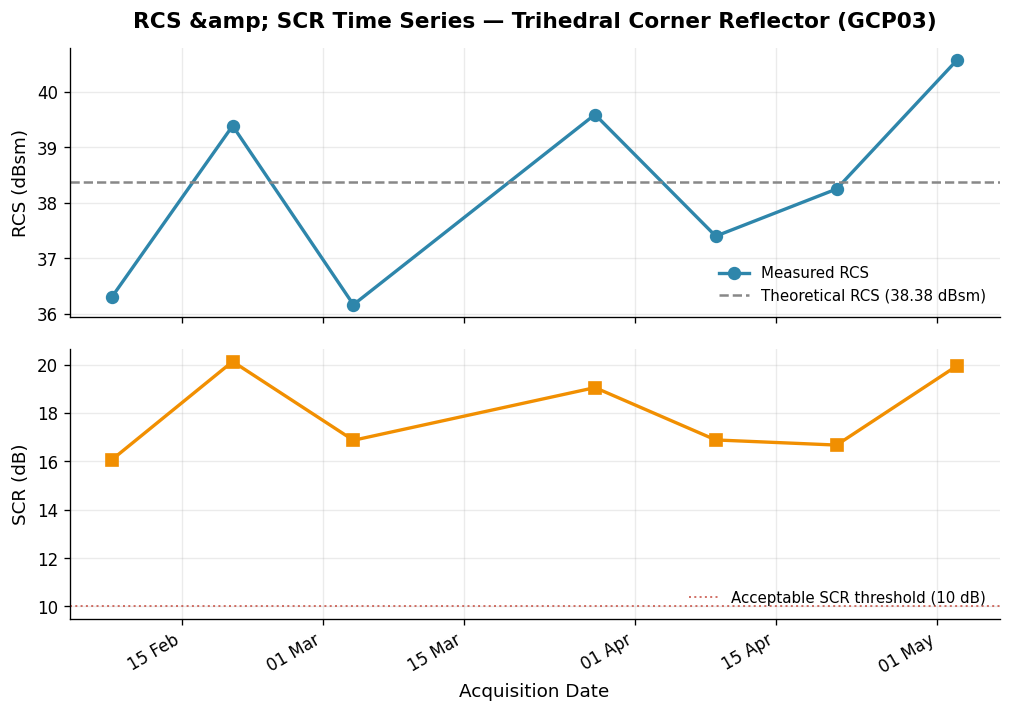

Figure saved to: /media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/RCS_SCR_timeseries_crossexclusion_clutternorm.png


In [127]:
THEORETICAL_RCS_DBSM = 38.38

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                gridspec_kw={"hspace": 0.12})

ax1.plot(df["Date"], df["RCS (dBsm)"], marker="o", markersize=7,
         linewidth=2, color="#2E86AB", label="Measured RCS")
ax1.axhline(THEORETICAL_RCS_DBSM, color="#888888", linestyle="--", linewidth=1.5,
            label=f"Theoretical RCS ({THEORETICAL_RCS_DBSM:.2f} dBsm)")
ax1.set_ylabel("RCS (dBsm)", fontsize=11)
ax1.set_title(f"RCS &amp; SCR Time Series — Trihedral Corner Reflector ({GCP_NAME})",
              fontsize=13, fontweight="bold", pad=12)
ax1.legend(loc="lower right", frameon=False, fontsize=9)

ax2.plot(df["Date"], df["SCR (dB)"], marker="s", markersize=7,
         linewidth=2, color="#F18F01")
ax2.axhline(10, color="#c0392b", linestyle=":", linewidth=1.2, alpha=0.7,
            label="Acceptable SCR threshold (10 dB)")
ax2.set_ylabel("SCR (dB)", fontsize=11)
ax2.set_xlabel("Acquisition Date", fontsize=11)
ax2.legend(loc="lower right", frameon=False, fontsize=9)

for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, pos: pd.to_datetime(x, unit="D", origin="1970-01-01").strftime("%d %b")))

fig.autofmt_xdate(rotation=30)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "RCS_SCR_timeseries_crossexclusion_clutternorm.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {plot_path}")

## 11. Spatial Visualization: Target Chip per Scene (Clutter-Normalized)

Each panel shows the mean-intensity image (dB) around the CR for one scene. The yellow box marks the clutter window and the red box marks the target window.

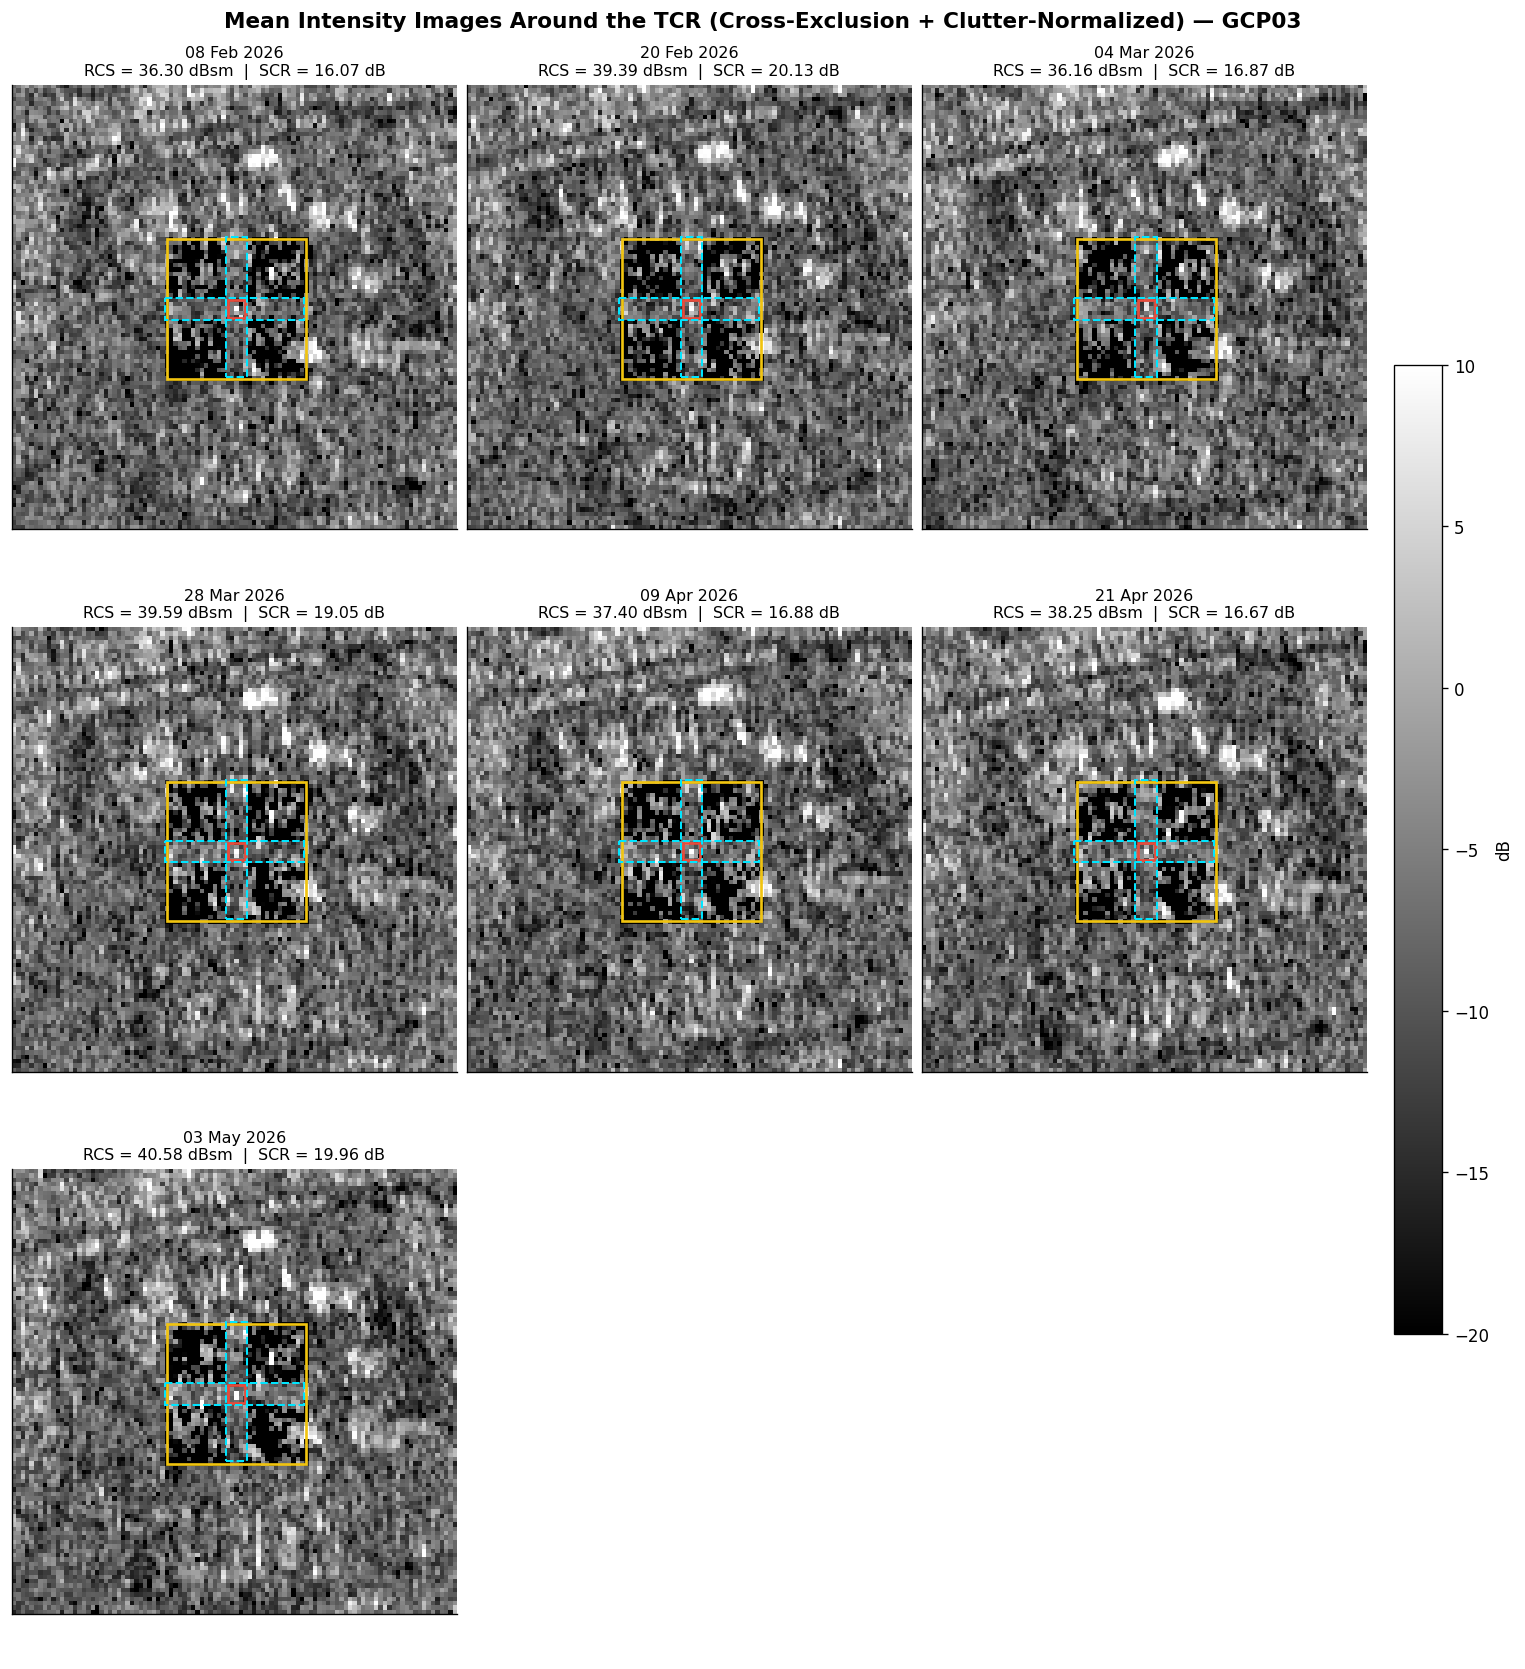

Grid figure saved to: /media/geospasial/storage_2/TESISZAKI/Radiometric/CoRAL-modif/RCSasc.png


In [128]:
n_scenes = len(files)
n_cols = min(n_scenes, 3)
n_rows = int(np.ceil(n_scenes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 4.6*n_rows),
                          constrained_layout=True)
axes = np.atleast_1d(axes).flatten()

for i, f in enumerate(files):
    scene_name = os.path.basename(f)
    band = band_map[scene_name]
    date_str = pd.to_datetime(scene_name.split("_")[5][:8], format="%Y%m%d").strftime("%d %b %Y")
    peak = peak_positions[scene_name]
    site_pos = np.array([peak["range"], peak["azimuth"]])

    data_dir = f.replace(".dim", ".data")
    band_path = os.path.join(data_dir, f"{band}.img")

    with rasterio.open(band_path) as src:
        d = src.read(1, window=Window(site_pos[0]-SUB_IM, site_pos[1]-SUB_IM, SUB_IM*2, SUB_IM*2))

    # Apply the same cross-excluded clutter normalization used for RCS/SCR (Section 7),
    # so the displayed image matches what was actually analyzed.
    d = d.astype(np.float64, copy=True)
    d[clutter_mask] = np.clip(d[clutter_mask] - GLOBAL_CLUTTER_MEDIAN, 0, None)

    db = 10*np.log10(np.clip(d, 1e-10, None))

    ax = axes[i]
    im = ax.matshow(db, cmap="gray", vmin=-20, vmax=10)
    ax.set_title(f"{date_str}\nRCS = {rcs[i]:.2f} dBsm  |  SCR = {scr[i]:.2f} dB", fontsize=9.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.xaxis.set_ticks_position("bottom")

    center = SUB_IM

    # Clutter window (yellow) -- outer boundary before cross-exclusion
    half_clt = CLT_WIN_SZ // 2
    ax.add_patch(plt.Rectangle((center-half_clt, center-half_clt), CLT_WIN_SZ, CLT_WIN_SZ,
                                edgecolor="#f1c40f", facecolor="none", linewidth=1.6))

    # Target window (red)
    half_targ = TARG_WIN_SZ // 2
    ax.add_patch(plt.Rectangle((center-half_targ, center-half_targ), TARG_WIN_SZ, TARG_WIN_SZ,
                                edgecolor="#e74c3c", facecolor="none", linewidth=1.6))

    # Cross-exclusion overlay (cyan) -- the plus-shaped region excluded from clutter
    # (and therefore also excluded from the median normalization), per Garthwaite et
    # al. (2015) Figure 4.11
    half_cross = CROSS_WIDTH / 2
    ax.axvspan(center-half_cross, center+half_cross,
               ymin=(center-half_clt)/db.shape[0], ymax=(center+half_clt)/db.shape[0],
               edgecolor="#00e5ff", facecolor="none", linewidth=1.2, linestyle="--")
    ax.axhspan(center-half_cross, center+half_cross,
               xmin=(center-half_clt)/db.shape[1], xmax=(center+half_clt)/db.shape[1],
               edgecolor="#00e5ff", facecolor="none", linewidth=1.2, linestyle="--")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Mean Intensity Images Around the TCR (Cross-Exclusion + Clutter-Normalized) — {GCP_NAME}",
             fontsize=13, fontweight="bold")
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.6, pad=0.02, label="dB")

grid_path = os.path.join(OUTPUT_DIR, "RCSasc.png")
plt.savefig(grid_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Grid figure saved to: {grid_path}")

## 12. Summary

| File | Description |
|---|---|
| `RCS_results_crossexclusion_clutternorm.csv` | Full table of RCS, SCR, resolved band, and pixel position per scene |
| `RCS_SCR_timeseries_crossexclusion_clutternorm.png` | Time-series plot of RCS and SCR |
| `RCS_timeseries_grid_crossexclusion_clutternorm.png` | Grid visualization of the target chip per scene, with cross-exclusion overlay |

**What this notebook combines:**
- **Cross-exclusion clutter window** (Section 8, via `loop_cross_exclusion`): clutter is defined as the four quadrants of the clutter window that lie outside a plus-shaped cross region of width `CROSS_WIDTH`, following Figure 4.11 of Garthwaite et al. (2015) -- instead of CoRAL's default square-annulus clutter window.
- **Global clutter median normalization** (Sections 6-7): a single median of cross-excluded clutter pixels, pooled across all scenes (linear sigma0 domain), is subtracted from cross-excluded clutter pixels only, floored at 0 to avoid `log10(<=0)`. Target-window pixels, cross-region pixels, and pixels outside the clutter window are never modified.
- Neither `coral/corner_reflector.py` nor `coral/dataio.py` is modified. All of this is implemented via `coral/cross_exclusion.py` (new module, reuses Garthwaite 2017 Eq. 2/7/8 unchanged) and a `readdimap` monkeypatch from within this notebook.

**Interpretation notes:**
- RCS values close to the theoretical value (38.38 dBsm) indicate that the TCR is functioning optimally and is unobstructed.
- SCR &lt; 10 dB indicates that the target signal approaches the clutter level; results for such scenes should be interpreted with caution.
- Scenes flagged as *split / single subswath* in Section 3 were terrain-corrected from a single IW subswath only; their resolved band name (`Sigma0_IW{n}_VV`) differs from full-swath scenes (`Sigma0_VV`), but RCS/SCR values remain directly comparable across both product types.
